# TC 5033
## Deep Learning
## Fully Connected Deep Neural Networks


#### Activity 1a: Implementing a Multilayer Fully Connected Network using Numpy
#### Non-graded activity (0 points)

- Name: Carlos Pano Hernandez - A01066264

- Objective

The primary objective of this activity is to deepen your understanding of Fully Connected Networks by implementing a multilayer network using only Numpy. You  are  given  the follosing starter code that solves the MNIST dataset problem. Your task is to read, understand, and then apply this knowledge to solve classification problems on other datasets such as the Kaggle ASL dataset (Starter code will be provided separately for that activity).

- Instructions

    Read and Understand the following Code: The provided starter code outlines the architecture of a Fully Connected Network designed to classify MNIST images. Go through the code to understand how each function and class is used to implement the network.

    Understand the Math: Make sure you understand the math operations implemented in the code, especially during the forward and backward passes. This will involve matrix multiplications, activation functions, loss computations, and backpropagation.
    
- Experiment
    You are encouraged to play with the code, change any hyperparameters and train the model, you should be able to achieve over 95% accuracy on the test set without problems.


In [46]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import string
import os
%matplotlib inline

# Import helper functions for better code organization
from helper_functions import (
    normalise,
    plot_number,
    np_tensor,
    Linear,
    ReLU,
    parallel_train_models
)

### Import Images

In [21]:
from get_images import get_images

In [22]:
# MNIST path
mnist_path = './mnist_raw/'
x_train_num, y_train_num, x_test_num, y_test_num = get_images(mnist_path)

x_train = x_train_num[:50000].reshape(50000, -1).astype(float)
y_train = y_train_num[:50000].reshape(50000, 1)

x_val = x_train_num[50000:].reshape(10000, -1).astype(float)
y_val = y_train_num[50000:].reshape(10000, 1)

x_test = x_test_num.copy().reshape(10000, -1).astype(float)
y_test = y_test_num.copy().reshape(10000, 1)

In [23]:
x_train.mean(), x_train.std(), x_train.min()

(np.float64(33.39512885204082), np.float64(78.6661972212754), np.float64(0.0))

In [24]:
x_mean = x_train.mean()
x_std = x_train.std()

x_train = normalise(x_mean, x_std, x_train)
x_val = normalise(x_mean, x_std, x_val)
x_test = normalise(x_mean, x_std, x_test)

In [25]:
x_train.mean(), x_train.std()

(np.float64(-9.646705203355238e-18), np.float64(0.9999999999999997))

### Plot samples

La imagen muestreada representa un: 7


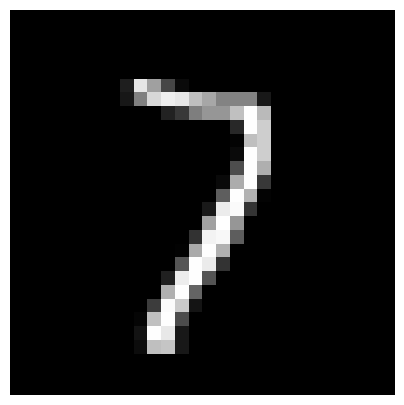

In [26]:
rnd_idx = np.random.randint(len(y_test))
print(f'La imagen muestreada representa un: {y_test[rnd_idx, 0]}')
plot_number(x_test_num[rnd_idx])

### Equations


$$z^1 = W^1 X + b^1$$

$$a^1 = ReLU(z^1) $$

$$z^2 = W^2 a^1 + b^2$$

$$\hat{y} = \frac{e^{z^{2_k}}}{\sum_j{e^{z_j}}}$$


$$ \mathcal{L}(\hat{y}^{i}, y^{i}) =  - y^{i}  \ln(\hat{y}^{i}) = -\ln(\hat{y}^i)$$


$$ \mathcal{J}(w, b) =  \frac{1}{num\_samples} \sum_{i=1}^{num\_samples}-\ln(\hat{y}^{i})$$

### Helper functions

## Nuestra clase Linear, ReLU y Sequential

In [27]:
a = np.array([0, 0])
b = a.view(np_tensor)

In [28]:
type(a)

numpy.ndarray

In [29]:
type(b)

helper_functions.np_tensor.np_tensor

In [30]:
a == b

np_tensor([ True,  True])

In [31]:
a is b

False

### Loop de entrenamiento

In [32]:
# Define multiple model configurations for parallel training
# Testing various architectures and hyperparameters to find the best model
model_configs = [
    # Original configuration
    {
        'layers': [
            Linear(784, 200),
            ReLU(),
            Linear(200, 200),
            ReLU(),
            Linear(200, 10)
        ],
        'mb_size': 512,
        'learning_rate': 1e-4,
        'epochs': 20
    },
    # Larger first hidden layer
    {
        'layers': [
            Linear(784, 256),
            ReLU(),
            Linear(256, 128),
            ReLU(),
            Linear(128, 10)
        ],
        'mb_size': 256,
        'learning_rate': 1e-3,
        'epochs': 25
    },
    # Deeper network
    {
        'layers': [
            Linear(784, 256),
            ReLU(),
            Linear(256, 128),
            ReLU(),
            Linear(128, 64),
            ReLU(),
            Linear(64, 10)
        ],
        'mb_size': 128,
        'learning_rate': 5e-4,
        'epochs': 30
    },
    # Wider network
    {
        'layers': [
            Linear(784, 400),
            ReLU(),
            Linear(400, 200),
            ReLU(),
            Linear(200, 10)
        ],
        'mb_size': 256,
        'learning_rate': 8e-4,
        'epochs': 25
    },
    # Smaller batch size, higher learning rate
    {
        'layers': [
            Linear(784, 200),
            ReLU(),
            Linear(200, 200),
            ReLU(),
            Linear(200, 10)
        ],
        'mb_size': 128,
        'learning_rate': 2e-3,
        'epochs': 30
    },
    # Three hidden layers with moderate sizes
    {
        'layers': [
            Linear(784, 300),
            ReLU(),
            Linear(300, 150),
            ReLU(),
            Linear(150, 75),
            ReLU(),
            Linear(75, 10)
        ],
        'mb_size': 256,
        'learning_rate': 1e-3,
        'epochs': 25
    }
]

In [33]:
# Use parallel training to test all configurations
results = parallel_train_models(
    model_configs, 
    x_train, y_train, 
    x_val, y_val, 
    x_test, y_test
)

# Extract the best model
best_result = results['best_result']
model = best_result['model']
mb_size = best_result['config']['mb_size']

print(f"\n✓ Using best model with {best_result['test_accuracy']*100:.2f}% test accuracy")

Starting parallel training for multiple configurations...

Training configuration 1/6...
costo: 0.3039, accuracy: 0.9225
costo: 0.2145, accuracy: 0.9378
costo: 0.1658, accuracy: 0.9465
costo: 0.2075, accuracy: 0.9526
costo: 0.1628, accuracy: 0.9562
costo: 0.1421, accuracy: 0.9610
costo: 0.1234, accuracy: 0.9622
costo: 0.1149, accuracy: 0.9637
costo: 0.0931, accuracy: 0.9653
costo: 0.1340, accuracy: 0.9663
costo: 0.0717, accuracy: 0.9685
costo: 0.0747, accuracy: 0.9680
costo: 0.0717, accuracy: 0.9707
costo: 0.0700, accuracy: 0.9714
costo: 0.0444, accuracy: 0.9713
costo: 0.0860, accuracy: 0.9713
costo: 0.0814, accuracy: 0.9740
costo: 0.0726, accuracy: 0.9725
costo: 0.0425, accuracy: 0.9730
costo: 0.0497, accuracy: 0.9742

Configuration:
  Layers: ['Linear', 'ReLU', 'Linear', 'ReLU', 'Linear']
  Mini-batch size: 512
  Learning rate: 0.0001
  Epochs: 20
  Test Accuracy: 0.9712 (97.12%)

Training configuration 2/6...
costo: 0.2334, accuracy: 0.9504
costo: 0.0623, accuracy: 0.9648
costo: 0.0

In [34]:
# Final test accuracy (already computed in parallel training)
print(f"Final Test Accuracy: {best_result['test_accuracy']:.4f} ({best_result['test_accuracy']*100:.2f}%)")

Final Test Accuracy: 0.9809 (98.09%)


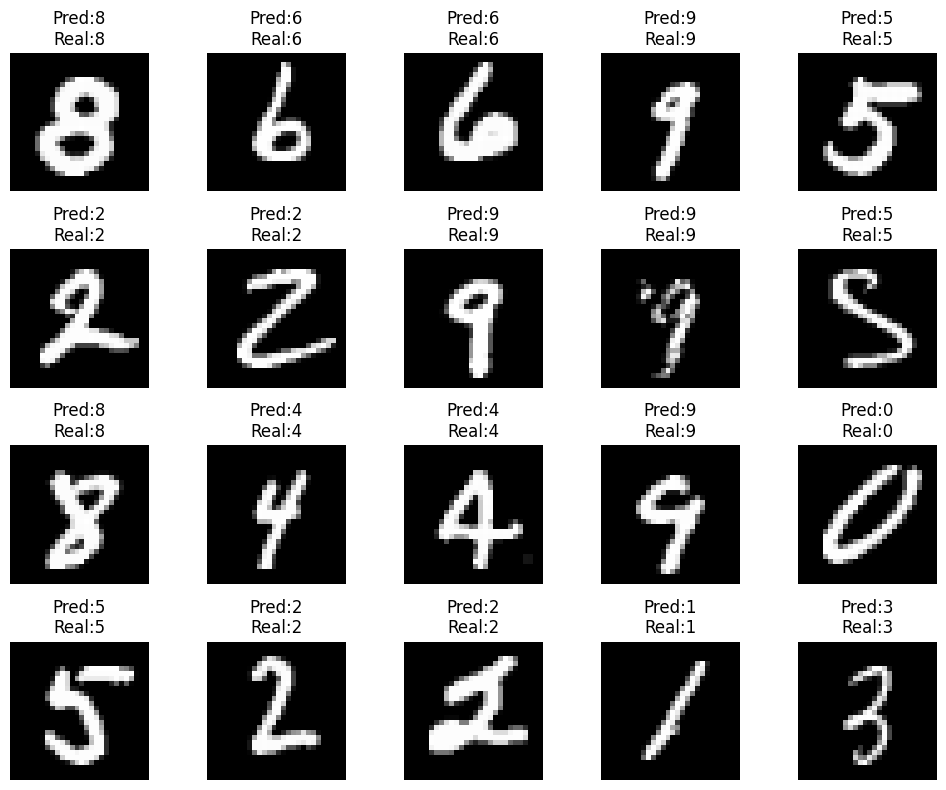

In [35]:
n_imgs = 20  # at least 20 images
n_cols = 5   # in columns (e.g., 5 columns, 4 rows)
n_rows = n_imgs // n_cols if n_imgs % n_cols == 0 else n_imgs // n_cols + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2, n_rows*2))

indices = np.random.choice(len(y_test), n_imgs, replace=False)
for i, idx in enumerate(indices):
    row, col = divmod(i, n_cols)
    ax = axes[row, col] if n_rows > 1 else axes[col]
    ax.imshow(x_test_num[idx], cmap='gray')
    pred = model.predict(x_test[idx].reshape(-1,1))
    ax.set_title(f'Pred:{pred}\nReal:{y_test[idx][0]}')
    ax.axis('off')

# Hide any unused subplots
for i in range(n_imgs, n_rows*n_cols):
    row, col = divmod(i, n_cols)
    ax = axes[row, col] if n_rows > 1 else axes[col]
    ax.axis('off')

plt.tight_layout()
plt.show()

---

## ASL Dataset Training

Now let's apply the same approach to the ASL (American Sign Language) dataset. The ASL dataset has 24 classes (letters a-z excluding j and z).

In [36]:
# Load ASL dataset
asl_data_path = './asl_data'
train_df = pd.read_csv(os.path.join(asl_data_path, 'sign_mnist_train.csv'))
valid_df = pd.read_csv(os.path.join(asl_data_path, 'sign_mnist_valid.csv'))

print(f"Training data shape: {train_df.shape}")
print(f"Validation data shape: {valid_df.shape}")
print(f"\nFirst few rows:")
train_df.head()

Training data shape: (27455, 785)
Validation data shape: (7172, 785)

First few rows:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,12,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [37]:
# Extract labels and features
y_train_asl = np.array(train_df['label'])
y_val_asl = np.array(valid_df['label'])

del train_df['label']
del valid_df['label']

x_train_asl = train_df.values.astype(np.float32)
x_val_asl = valid_df.values.astype(np.float32)

print(f"Training: {x_train_asl.shape}, Labels: {y_train_asl.shape}")
print(f"Validation: {x_val_asl.shape}, Labels: {y_val_asl.shape}")

Training: (27455, 784), Labels: (27455,)
Validation: (7172, 784), Labels: (7172,)


In [38]:
# Split validation into validation and test sets
def split_val_test(x_val, y_val, test_ratio=0.5):
    """
    Split validation set into validation and test sets.
    
    Parameters:
    -----------
    x_val : numpy array
        Validation features
    y_val : numpy array
        Validation labels
    test_ratio : float
        Ratio of validation set to use for test set (default 0.5)
    
    Returns:
    --------
    x_val_new, y_val_new, x_test, y_test
    """
    n_samples = len(x_val)
    n_test = int(n_samples * test_ratio)
    
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    
    test_indices = indices[:n_test]
    val_indices = indices[n_test:]
    
    x_test = x_val[test_indices]
    y_test = y_val[test_indices]
    x_val_new = x_val[val_indices]
    y_val_new = y_val[val_indices]
    
    return x_val_new, y_val_new, x_test, y_test

x_val_asl, y_val_asl, x_test_asl, y_test_asl = split_val_test(x_val_asl, y_val_asl)

print(f"Training: {x_train_asl.shape}, Labels: {y_train_asl.shape}")
print(f"Validation: {x_val_asl.shape}, Labels: {y_val_asl.shape}")
print(f"Test: {x_test_asl.shape}, Labels: {y_test_asl.shape}")

# ASL alphabet (24 classes: a-z excluding j and z)
alphabet = list(string.ascii_lowercase)
alphabet.remove('j')
alphabet.remove('z')
print(f"\nASL has {len(alphabet)} classes: {alphabet}")

Training: (27455, 784), Labels: (27455,)
Validation: (3586, 784), Labels: (3586,)
Test: (3586, 784), Labels: (3586,)

ASL has 24 classes: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y']


In [39]:
# Normalize ASL data
x_mean_asl = x_train_asl.mean()
x_std_asl = x_train_asl.std()

x_train_asl = normalise(x_mean_asl, x_std_asl, x_train_asl)
x_val_asl = normalise(x_mean_asl, x_std_asl, x_val_asl)
x_test_asl = normalise(x_mean_asl, x_std_asl, x_test_asl)

print(f"Training data - Mean: {x_train_asl.mean():.6f}, Std: {x_train_asl.std():.6f}")
print(f"Validation data - Mean: {x_val_asl.mean():.6f}, Std: {x_val_asl.std():.6f}")
print(f"Test data - Mean: {x_test_asl.mean():.6f}, Std: {x_test_asl.std():.6f}")

Training data - Mean: 0.000004, Std: 0.999999
Validation data - Mean: 0.018256, Std: 1.003968
Test data - Mean: 0.034248, Std: 1.007162


La imagen muestreada representa la letra: d


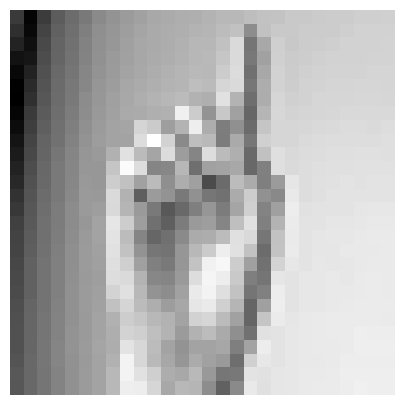

In [40]:
# Display a random sample from ASL training data
rnd_idx_asl = np.random.randint(len(y_train_asl))
print(f'La imagen muestreada representa la letra: {alphabet[y_train_asl[rnd_idx_asl]]}')
plot_number(x_train_asl[rnd_idx_asl].reshape(28, 28))

### Train ASL Models with Parallel Training

We'll test multiple architectures to find the best model for ASL classification (24 classes).

In [41]:
# Define multiple model configurations for ASL dataset (24 output classes)
asl_model_configs = [
    # Configuration 1: Moderate size
    {
        'layers': [
            Linear(784, 256),
            ReLU(),
            Linear(256, 128),
            ReLU(),
            Linear(128, 24)  # 24 ASL classes
        ],
        'mb_size': 256,
        'learning_rate': 1e-3,
        'epochs': 30
    },
    # Configuration 2: Larger first hidden layer
    {
        'layers': [
            Linear(784, 512),
            ReLU(),
            Linear(512, 128),
            ReLU(),
            Linear(128, 24)
        ],
        'mb_size': 128,
        'learning_rate': 5e-4,
        'epochs': 35
    },
    # Configuration 3: Deeper network
    {
        'layers': [
            Linear(784, 256),
            ReLU(),
            Linear(256, 128),
            ReLU(),
            Linear(128, 64),
            ReLU(),
            Linear(64, 24)
        ],
        'mb_size': 128,
        'learning_rate': 5e-4,
        'epochs': 30
    },
    # Configuration 4: Wider network
    {
        'layers': [
            Linear(784, 400),
            ReLU(),
            Linear(400, 200),
            ReLU(),
            Linear(200, 24)
        ],
        'mb_size': 256,
        'learning_rate': 8e-4,
        'epochs': 25
    },
    # Configuration 5: Smaller batch size, higher learning rate
    {
        'layers': [
            Linear(784, 256),
            ReLU(),
            Linear(256, 128),
            ReLU(),
            Linear(128, 24)
        ],
        'mb_size': 128,
        'learning_rate': 2e-3,
        'epochs': 30
    },
    # Configuration 6: Three hidden layers
    {
        'layers': [
            Linear(784, 300),
            ReLU(),
            Linear(300, 150),
            ReLU(),
            Linear(150, 75),
            ReLU(),
            Linear(75, 24)
        ],
        'mb_size': 256,
        'learning_rate': 1e-3,
        'epochs': 25
    }
]

In [42]:
# Use parallel training to test all ASL configurations
asl_results = parallel_train_models(
    asl_model_configs, 
    x_train_asl, y_train_asl, 
    x_val_asl, y_val_asl, 
    x_test_asl, y_test_asl
)

# Extract the best ASL model
asl_best_result = asl_results['best_result']
asl_model = asl_best_result['model']
asl_mb_size = asl_best_result['config']['mb_size']

print(f"\n✓ Using best ASL model with {asl_best_result['test_accuracy']*100:.2f}% test accuracy")

Starting parallel training for multiple configurations...

Training configuration 1/6...
costo: 0.0586, accuracy: 0.7479
costo: 0.0139, accuracy: 0.7677
costo: 0.0065, accuracy: 0.7727
costo: 0.0045, accuracy: 0.7777
costo: 0.0035, accuracy: 0.7786
costo: 0.0026, accuracy: 0.7772
costo: 0.0023, accuracy: 0.7830
costo: 0.0042, accuracy: 0.7825
costo: 0.0017, accuracy: 0.7797
costo: 0.0021, accuracy: 0.7839
costo: 0.0014, accuracy: 0.7853
costo: 0.0015, accuracy: 0.7833
costo: 0.0014, accuracy: 0.7819
costo: 0.0012, accuracy: 0.7842
costo: 0.0009, accuracy: 0.7833
costo: 0.0008, accuracy: 0.7858
costo: 0.0015, accuracy: 0.7853
costo: 0.0008, accuracy: 0.7819
costo: 0.0008, accuracy: 0.7867
costo: 0.0006, accuracy: 0.7844
costo: 0.0006, accuracy: 0.7853
costo: 0.0005, accuracy: 0.7850
costo: 0.0006, accuracy: 0.7844
costo: 0.0005, accuracy: 0.7856
costo: 0.0005, accuracy: 0.7850
costo: 0.0006, accuracy: 0.7853
costo: 0.0008, accuracy: 0.7847
costo: 0.0008, accuracy: 0.7853
costo: 0.0004, 

In [43]:
# Final ASL test accuracy
print(f"Final ASL Test Accuracy: {asl_best_result['test_accuracy']:.4f} ({asl_best_result['test_accuracy']*100:.2f}%)")

# Check if we met the requirement (≥70% accuracy)
if asl_best_result['test_accuracy'] >= 0.70:
    print(f"✓ Requirement met! Accuracy ≥ 70%")
else:
    print(f"✗ Requirement not met. Need ≥ 70% accuracy")

Final ASL Test Accuracy: 0.8277 (82.77%)
✓ Requirement met! Accuracy ≥ 70%


### Test ASL Model on Random Samples

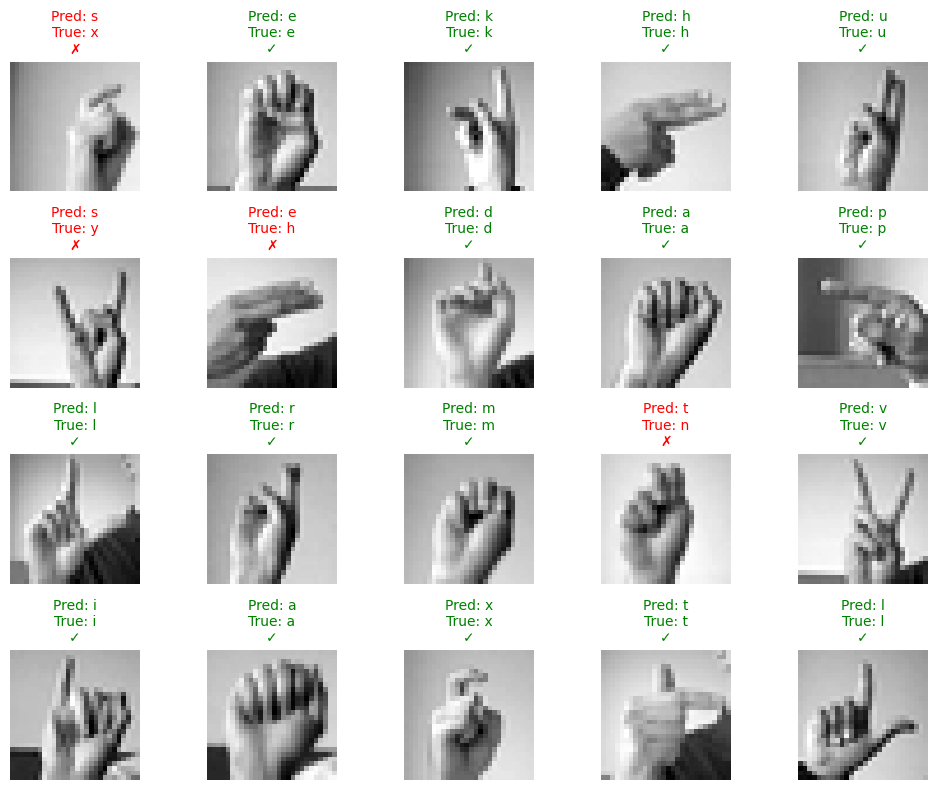

In [44]:
# Test on random samples from ASL test set
n_imgs_asl = 20
n_cols_asl = 5
n_rows_asl = n_imgs_asl // n_cols_asl if n_imgs_asl % n_cols_asl == 0 else n_imgs_asl // n_cols_asl + 1

fig, axes = plt.subplots(n_rows_asl, n_cols_asl, figsize=(n_cols_asl*2, n_rows_asl*2))

indices_asl = np.random.choice(len(y_test_asl), n_imgs_asl, replace=False)
for i, idx in enumerate(indices_asl):
    row, col = divmod(i, n_cols_asl)
    ax = axes[row, col] if n_rows_asl > 1 else axes[col]
    ax.imshow(x_test_asl[idx].reshape(28, 28), cmap='gray')
    pred = asl_model.predict(x_test_asl[idx].reshape(-1, 1))
    true_label = y_test_asl[idx]
    is_correct = "✓" if pred == true_label else "✗"
    ax.set_title(f'Pred: {alphabet[pred]}\nTrue: {alphabet[true_label]}\n{is_correct}', 
                 fontsize=10,
                 color='green' if is_correct == "✓" else 'red')
    ax.axis('off')

# Hide any unused subplots
for i in range(n_imgs_asl, n_rows_asl*n_cols_asl):
    row, col = divmod(i, n_cols_asl)
    ax = axes[row, col] if n_rows_asl > 1 else axes[col]
    ax.axis('off')

plt.tight_layout()
plt.show()